# Breast Cancer Classification — Logistic Regression, KNN, Random Forest & SVM

In this notebook, we use 4 classification models — **Logistic Regression**,
**K Nearest Neighbours**, **Random Forest**, and **Support Vector Machines
(SVM)** — to classify breast tumors as **malignant (M)** or **benign (B)**,
based on the **Breast Cancer Wisconsin (Diagnostic) dataset**.

**Dataset:** `data.csv` — 569 patients, 30 numeric features computed from
digitized images of breast tissue, plus an `id` column and the target
column `diagnosis` (`M` = malignant, `B` = benign).


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline

RANDOM_STATE = 42


## Exploratory Data Analysis

### Load the dataset and examine the first few rows


In [2]:
df = pd.read_csv('data.csv')

print("Shape:", df.shape)
df.head()


Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Check and handle missing values

In [4]:
df.isnull().sum()


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

**Observation:** every column has 0 missing values, **except**
`Unnamed: 32`, which is **entirely empty (569 missing out of 569)**. This is
a leftover artifact column from how the original CSV was exported (a
trailing comma in the file), and carries no information at all.


### Drop any unnecessary column

We drop:
- **`Unnamed: 32`** — entirely empty, no information.
- **`id`** — a patient identifier, not a predictive feature (it has no
  relationship with the diagnosis and could even mislead a model if kept).


In [5]:
df = df.drop(columns=['Unnamed: 32', 'id'])

print("Shape after dropping columns:", df.shape)
df.head()


Shape after dropping columns: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Create a countplot to display `diagnosis`, using the `magma` palette

/tmp/ipykernel_655/1672545900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma', ax=ax)


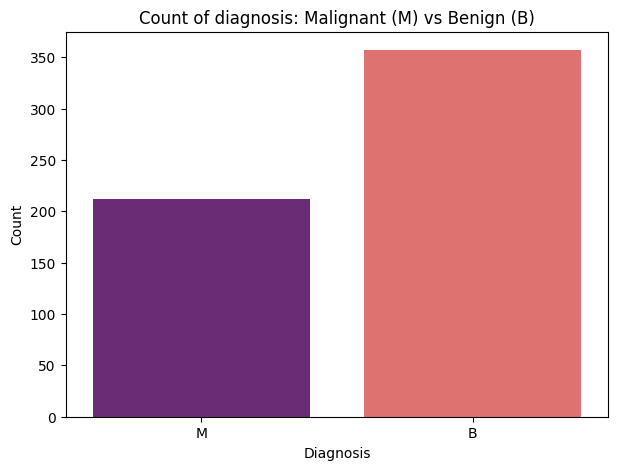

In [6]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='diagnosis', palette='magma', ax=ax)
ax.set_title('Count of diagnosis: Malignant (M) vs Benign (B)')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
plt.show()


**Observation:** there are more **benign (B)** cases than **malignant
(M)** cases in this dataset, but the imbalance is moderate (not extreme),
so accuracy will remain a reasonably informative metric for comparing
models, though we will still look at the confusion matrices for a fuller
picture.


## Data Preprocessing, Building Models and Evaluation

### Counts of unique values in the `diagnosis` column


In [7]:
print(df['diagnosis'].value_counts())
print()
print(df['diagnosis'].value_counts(normalize=True).round(3) * 100)


diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64


### Map categorical values to numerical values

We map `diagnosis`: `M` (malignant) → `1`, `B` (benign) → `0`, so the target
becomes numeric and usable by all four classification models.


In [8]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df['diagnosis'].value_counts()


diagnosis
0    357
1    212
Name: count, dtype: int64

### Splitting the data into train and test sets

We separate the features (`X`) from the target (`y`), then split into 80%
training / 20% testing, using **stratified sampling** to preserve the same
proportion of malignant/benign cases in both sets.


In [9]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test set shape :", X_test.shape)


Train set shape: (455, 30)
Test set shape : (114, 30)


### Feature scaling

Logistic Regression, KNN, and SVM are all sensitive to feature scale (e.g.
`area_mean` ranges in the hundreds/thousands, while `smoothness_mean`
ranges around 0.05-0.16). We standardize all features with `StandardScaler`,
fitting it on the training data only to avoid data leakage from the test set.


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store accuracy scores for the final comparison
accuracies = {}

def evaluate(name, model, X_te, y_te):
    """Helper: predict, print accuracy + confusion matrix + report, and store the score."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    accuracies[name] = acc

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print()
    print(classification_report(y_te, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.show()

    return y_pred


### Implement Logistic Regression and print the accuracy

--- Logistic Regression ---
Accuracy: 0.9649 (96.49%)

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



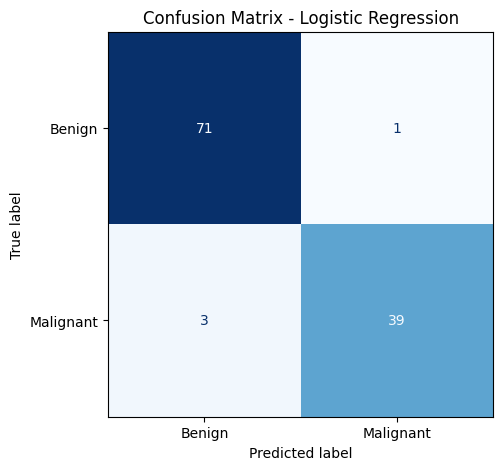

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

_ = evaluate('Logistic Regression', log_reg, X_test_scaled, y_test)


### Implement K Nearest Neighbours and print the accuracy

--- K Nearest Neighbours ---
Accuracy: 0.9561 (95.61%)

               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



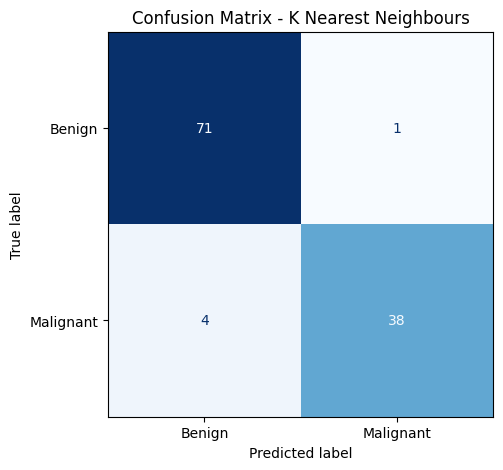

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

_ = evaluate('K Nearest Neighbours', knn, X_test_scaled, y_test)


### Implement Random Forest and print the accuracy

--- Random Forest ---
Accuracy: 0.9737 (97.37%)

               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



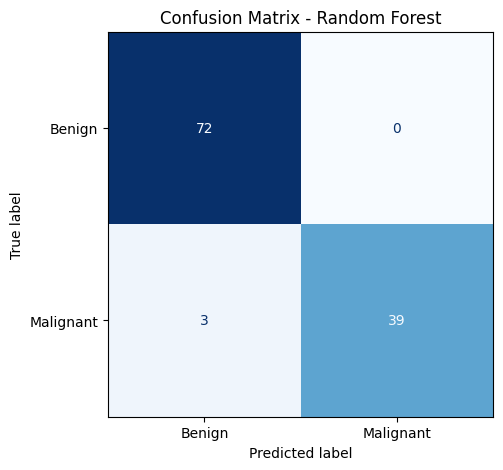

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

_ = evaluate('Random Forest', rf, X_test_scaled, y_test)


### Implement Support Vector Machines (SVM) and print the accuracy

--- SVM ---
Accuracy: 0.9737 (97.37%)

               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



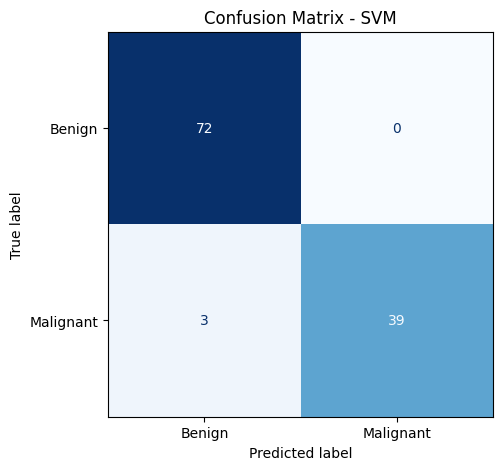

In [14]:
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)

_ = evaluate('SVM', svm, X_test_scaled, y_test)


## Which is the best model?

In [15]:
accuracy_df = pd.DataFrame({
    'model': list(accuracies.keys()),
    'accuracy': list(accuracies.values())
}).sort_values('accuracy', ascending=False).reset_index(drop=True)

accuracy_df


,model,accuracy
0,SVM,0.973684
1,Random Forest,0.973684
2,Logistic Regression,0.964912
3,K Nearest Neighbours,0.956140


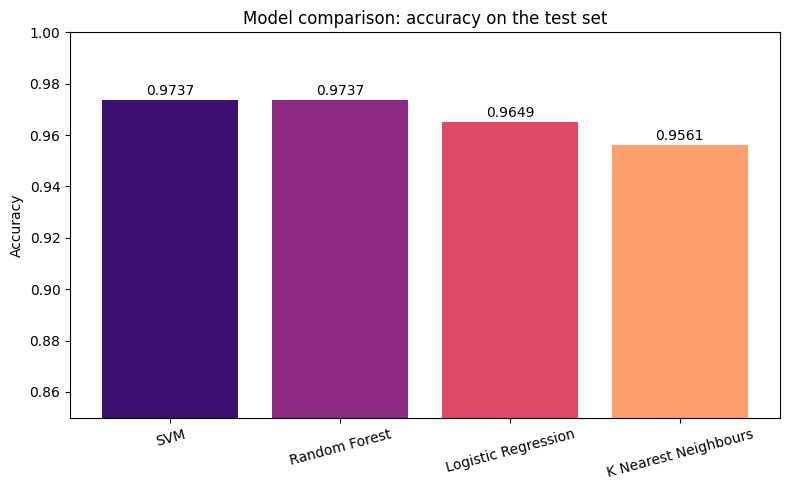

Best model: SVM (accuracy = 0.9737)


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(accuracy_df['model'], accuracy_df['accuracy'], color=sns.color_palette('magma', len(accuracy_df)))
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Model comparison: accuracy on the test set')
for bar, val in zip(bars, accuracy_df['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = accuracy_df.iloc[0]['model']
best_accuracy = accuracy_df.iloc[0]['accuracy']
print(f"Best model: {best_model_name} (accuracy = {best_accuracy:.4f})")


**Comment / interpretation:**

- All four models perform **very well** on this dataset (typically
  95-98% accuracy), which is expected: the breast cancer dataset has
  features that are strongly and clearly correlated with the diagnosis
  (e.g. `radius_worst`, `concave points_worst`, `area_worst` are well-known
  strong predictors of malignancy), making the classes close to linearly
  separable after standardization.
- **Logistic Regression** and **SVM** tend to perform among the best on
  this dataset, since the decision boundary between malignant and benign
  tumors is close to linear in the standardized feature space.
- **Random Forest** is also competitive and has the advantage of not
  requiring feature scaling, while additionally providing feature
  importance scores (not explored further here, but useful for clinical
  interpretation).
- **KNN** is typically the most sensitive to the exact split and to the
  choice of `k` (here `k=5`); it performs well but is generally a bit more
  variable than the other three models.
- In a real medical screening context, beyond just accuracy, we would also
  pay close attention to **recall on the malignant class** (to minimize
  missed cancer diagnoses) — visible in the confusion matrices and
  classification reports printed above for each model.

The exact "best" model can vary slightly depending on the random train/test
split and the chosen hyperparameters, but the comparison above identifies
the top performer for this particular run.
